In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , PolynomialFeatures
from sklearn.linear_model import LinearRegression , Ridge , LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error , r2_score , accuracy_score

In [2]:
df = pd.read_csv("F://Ml-Projects//Data//house_price//cleaned_train_data.csv" , index_col=False)
df

,Unnamed: 0,mssubclass,mszoning,lotfrontage,lotarea,street,lotshape,landcontour,utilities,lotconfig,...,enclosedporch,3ssnporch,screenporch,poolarea,miscval,mosold,yrsold,saletype,salecondition,saleprice
0,0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,142125


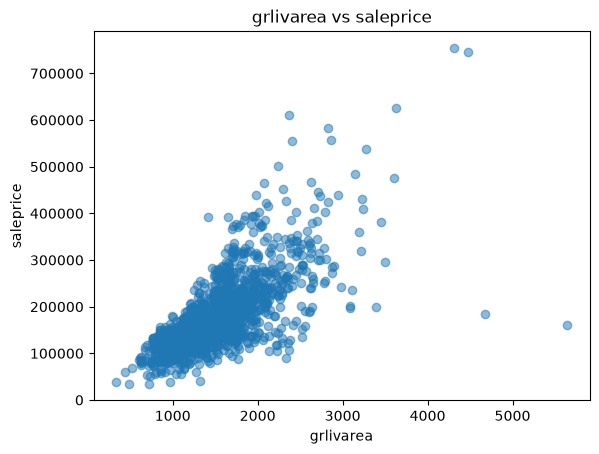

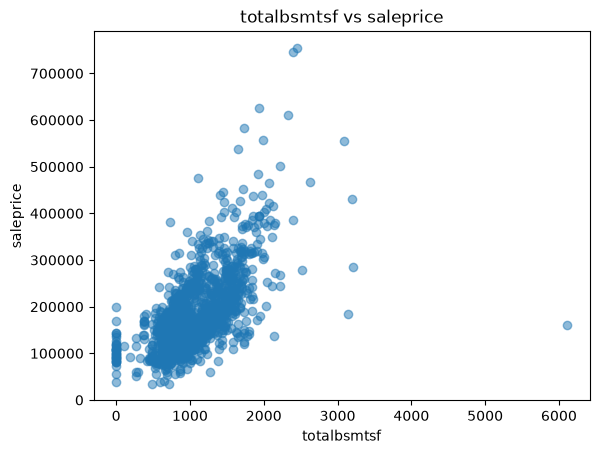

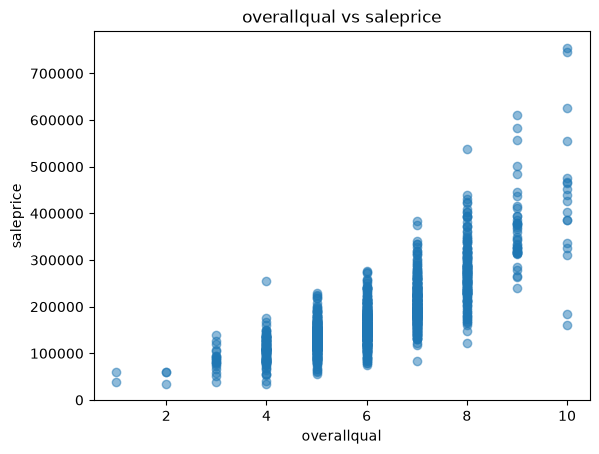

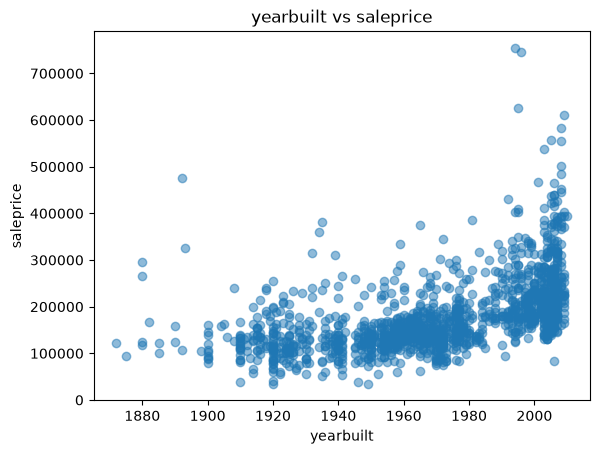

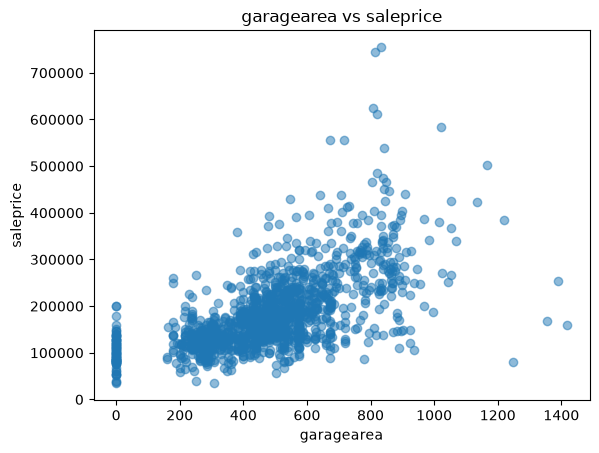

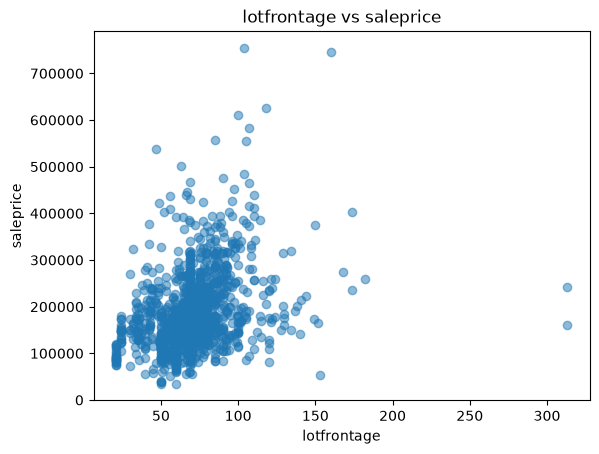

In [3]:
important_cols = ['grlivarea', 'totalbsmtsf', 'overallqual', 'yearbuilt', 'garagearea', 'lotfrontage']
required = "saleprice"

for col in important_cols:
    plt.scatter(df[col] , df[required] , alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(required)
    plt.title(f"{col} vs {required}")
    plt.show()

In [7]:
test = pd.read_csv("F://Ml-Projects//Data//house_price//cleaned_test_data.csv")

In [8]:
df['is_train'] = 1
test['is_train'] = 0
combined = pd.concat([df, test], axis=0)

combined_encoded = pd.get_dummies(combined)

train_encoded = combined_encoded[combined_encoded['is_train'] == 1].drop('is_train', axis=1)
test_encoded = combined_encoded[combined_encoded['is_train'] == 0].drop(['is_train', 'saleprice'], axis=1)

In [9]:
x = train_encoded.drop(columns=['saleprice'])
y = train_encoded[required]

x_train , x_temp , y_train , y_temp = train_test_split(x,y,test_size=0.30,random_state=42)
x_val , x_test , y_val , y_test = train_test_split(x , y , test_size=0.50 , random_state=42)

In [10]:
pipe_linear = Pipeline([
    ("Scaler" , StandardScaler()),
    ("model" , Ridge(alpha=10))
])
pipe_linear.fit(x_train , y_train)

y_pred_train = pipe_linear.predict(x_train)
y_pred_value = pipe_linear.predict(x_val)

print("Root Mean sqr error")
print(f"Training data: {np.sqrt(mean_squared_error(y_train , y_pred_train)):.4f}")
print(f"Training value: {np.sqrt(mean_squared_error(y_val , y_pred_value)):.4f}")
print(f"r2 score : {r2_score(y_val , y_pred_value):.2f}")

Root Mean sqr error
Training data: 19828.7962
Training value: 19278.8430
r2 score : 0.94


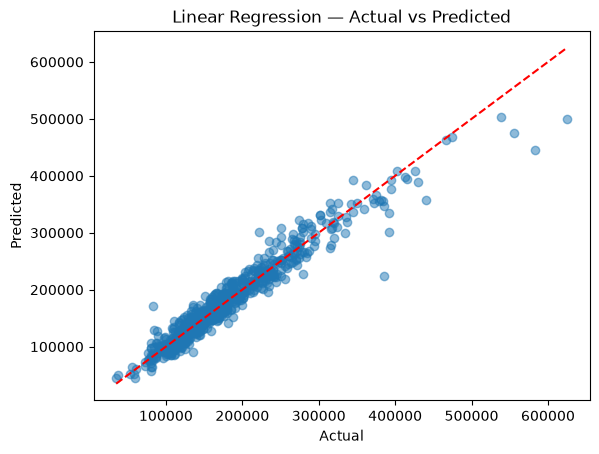

In [11]:
plt.scatter(y_val, y_pred_value, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],[y_val.min(), y_val.max()], 'r--')   
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression — Actual vs Predicted')
plt.show()

In [12]:
test_rmse = np.sqrt(mean_squared_error(y_test , pipe_linear.predict(x_test)))
print(f"The rmse value for test is {test_rmse:.4f}") 

The rmse value for test is 24716.4688


In [13]:
testing_df = pd.read_csv("F://Ml-Projects//Data//house_price//cleaned_test_data.csv" , index_col=False)
raw_testing_df = pd.read_csv("F://Ml-Projects//Data//house_price//test (1).csv")
house_ids = raw_testing_df["Id"]

train_cols = x.columns.tolist()  
testing_df = testing_df.reindex(columns=train_cols, fill_value=0)
testing_df = testing_df.fillna(0)

final_predict = pipe_linear.predict(testing_df)

submission = pd.DataFrame({
    "Id" : house_ids,
    "SalePrice" : final_predict
})

submission.to_csv("F://Ml-Projects//House_Price//Ml_prediction//finalprediction.csv" , index=False)